In [ ]:
!pip install Unidecode

In [ ]:
!pip install wordcloud

In [ ]:
#hide
!pip install transformers

In [ ]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
#text preprocessing libraries
import pandas as pd
import re
from unidecode import unidecode
from string import punctuation
import nltk
from nltk import sent_tokenize
from nltk import word_tokenize
from nltk.corpus import stopwords

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

In [ ]:
#text classification libraries
from transformers import BertTokenizer, BertForSequenceClassification
import seaborn as sns
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import train_test_split

## Loading data

In [ ]:
url = 'https://drive.google.com/file/d/15MTMse9MdIv-0-0yBtfkqks-5477e-R1/view?usp=sharing'
file_id = url.split('/')[-2]
read_url='https://drive.google.com/uc?id=' + file_id

# read the data
dataset = pd.read_csv(read_url, usecols=['text', 'hatespeech_comb'])

# display the first 5 rows
dataset.head()

,text,hatespeech_comb
0,@__andrea__b \nO cara vive em outro mundo\nNão...,1
1,@_carmeloneto Estes incompetentes não cuidam n...,0
2,@_carmeloneto \nOs 'cumpanhero' quebraram toda...,0
3,@_GlitteryKisses é isso não conseguem pensar n...,0
4,@_iglira bom dia macaco branco haha,1


In [ ]:
#dataset['target'].replace(to_replace=[0, 1], value=['negative', 'positive'], inplace = True)

In [ ]:
# display the first 5 rows
#trocar nome da coluna para target
dataset = dataset.rename(columns={'hatespeech_comb': 'target'})
dataset.head()


,text,target
0,@__andrea__b \nO cara vive em outro mundo\nNão...,1
1,@_carmeloneto Estes incompetentes não cuidam n...,0
2,@_carmeloneto \nOs 'cumpanhero' quebraram toda...,0
3,@_GlitteryKisses é isso não conseguem pensar n...,0
4,@_iglira bom dia macaco branco haha,1


## **Data pre-processing**

In [ ]:
nltk.download('rslp')
nltk.download('stopwords')
stopwords_list = stopwords.words("portuguese")
print(stopwords_list)

['a', 'à', 'ao', 'aos', 'aquela', 'aquelas', 'aquele', 'aqueles', 'aquilo', 'as', 'às', 'até', 'com', 'como', 'da', 'das', 'de', 'dela', 'delas', 'dele', 'deles', 'depois', 'do', 'dos', 'e', 'é', 'ela', 'elas', 'ele', 'eles', 'em', 'entre', 'era', 'eram', 'éramos', 'essa', 'essas', 'esse', 'esses', 'esta', 'está', 'estamos', 'estão', 'estar', 'estas', 'estava', 'estavam', 'estávamos', 'este', 'esteja', 'estejam', 'estejamos', 'estes', 'esteve', 'estive', 'estivemos', 'estiver', 'estivera', 'estiveram', 'estivéramos', 'estiverem', 'estivermos', 'estivesse', 'estivessem', 'estivéssemos', 'estou', 'eu', 'foi', 'fomos', 'for', 'fora', 'foram', 'fôramos', 'forem', 'formos', 'fosse', 'fossem', 'fôssemos', 'fui', 'há', 'haja', 'hajam', 'hajamos', 'hão', 'havemos', 'haver', 'hei', 'houve', 'houvemos', 'houver', 'houvera', 'houverá', 'houveram', 'houvéramos', 'houverão', 'houverei', 'houverem', 'houveremos', 'houveria', 'houveriam', 'houveríamos', 'houvermos', 'houvesse', 'houvessem', 'houvésse

[nltk_data] Downloading package rslp to /root/nltk_data...
[nltk_data]   Package rslp is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
data_process = dataset.copy()

dataset.columns

Index(['text', 'target'], dtype='object')

In [ ]:
old_texts = data_process["text"]
new_texts = []

for text in old_texts:
    # Remove menções (@usuario)
    text = re.sub(r'@\S+', '', text)

    # Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)

    # Remove espaços extras gerados pela remoção
    text = re.sub(r'\s+', ' ', text).strip()

    new_texts.append(text)

data_process["text"] = new_texts

In [ ]:
data_process

,text,target
0,O cara vive em outro mundo Não no mundo real R...,1
1,Estes incompetentes não cuidam nem do povo bra...,0
2,Os 'cumpanhero' quebraram todas as regras.,0
3,é isso não conseguem pensar no sentido lato pa...,0
4,bom dia macaco branco haha,1
...,...,...
5665,é o unico que nao se corrompe..nao se vende.. ...,0
5666,"sei das cotas, mas não sabia disso, putaria da...",1
5667,"sim, a maioria do eleitorado é mulher, 51%",0
5668,"seguir no tt é facíl, apresentar as amigas sap...",1


## **Dataset balancing**

<Axes: xlabel='target', ylabel='count'>

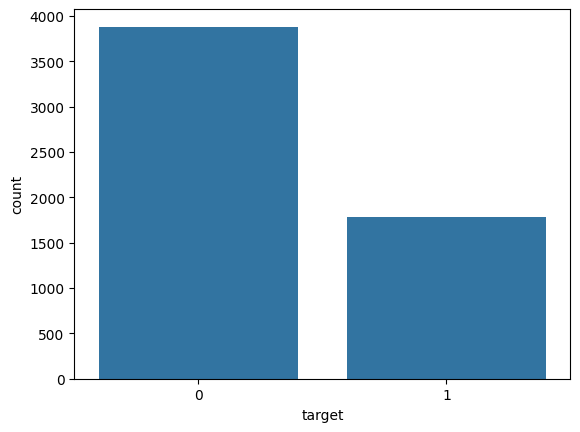

In [ ]:
sns.countplot(x = data_process['target'])

<Axes: xlabel='target', ylabel='count'>

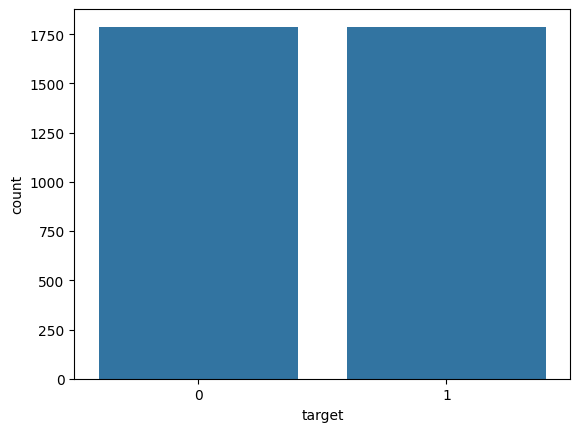

In [ ]:
rus = RandomUnderSampler(random_state= 0)
X_bal, Y_bal = rus.fit_resample(data_process[['text']], data_process['target'])
sns.countplot(x = Y_bal)

## **Words cloud**

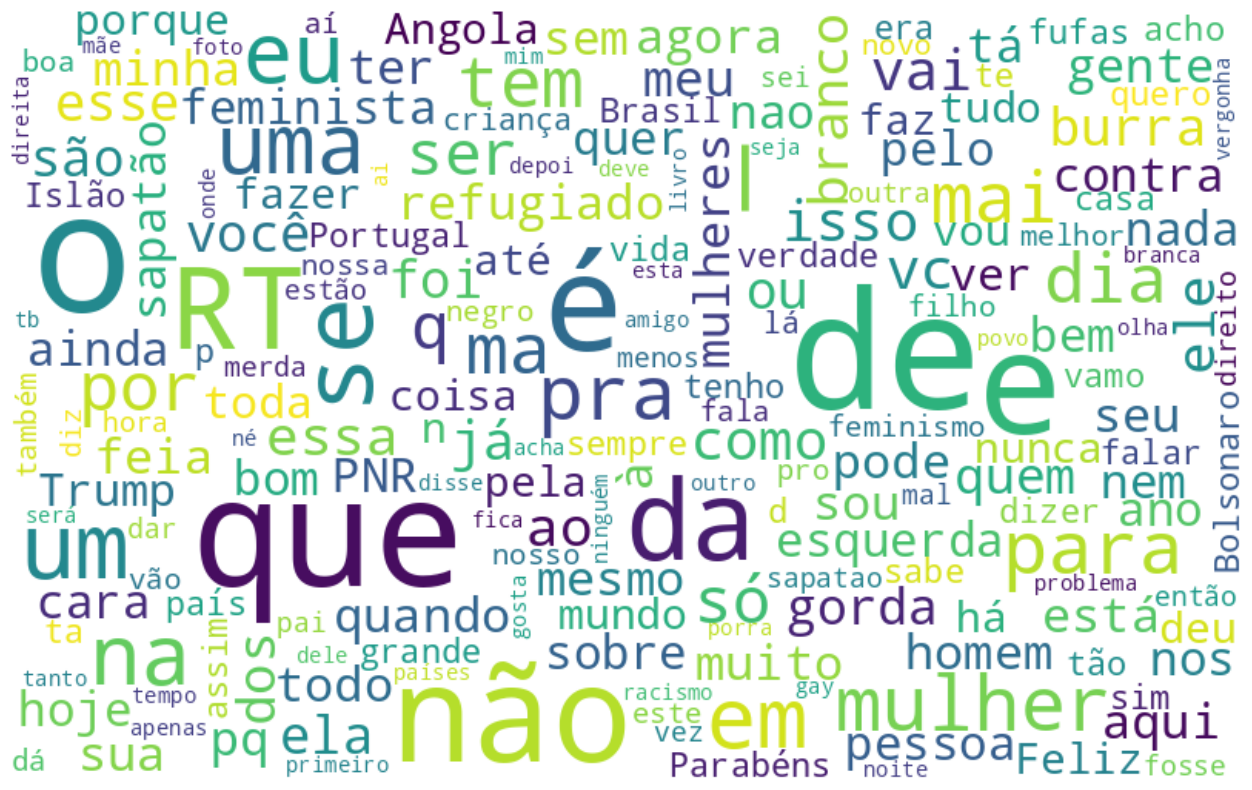

In [ ]:
new_texts = data_process["text"]
all_words = ' '.join([text for text in new_texts])
word_cloud = WordCloud(width= 800, height= 500, max_font_size = 110, background_color="white", collocations = False).generate(all_words)
plt.figure(figsize=(20,10))
plt.imshow(word_cloud, interpolation='bilinear')
plt.axis("off")
plt.show()

## **Cross validation: K-fold**

In [ ]:
train_df, test_df, train_label, test_label = train_test_split(X_bal, Y_bal, test_size=0.20, random_state=42)

In [ ]:
train_df, valid_df, train_label,  valid_label = train_test_split(train_df, train_label, test_size=0.20, random_state=42)

## Tokenization

Tokenization is a process for spliting raw texts into tokens, and encoding the tokens into numeric data.

To do this, we first initialize a `BertTokenizer`:

In [ ]:
# Load the BERT tokenizer.
#tokenizer = BertTokenizer.from_pretrained('neuralmind/bert-large-portuguese-cased', do_lower_case=True)
#neuralmind/bert-base-portuguese-cased
#neuralmind/bert-large-portuguese-cased
#bert-base-multilingual-cased
# bert-base-uncased

In [ ]:
PRETRAINED_LM = 'bert-base-multilingual-cased'
tokenizer = BertTokenizer.from_pretrained(PRETRAINED_LM, do_lower_case=True)
tokenizer

BertTokenizer(name_or_path='bert-base-multilingual-cased', vocab_size=119547, model_max_length=512, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
})

define a function for encoding:

In [ ]:
def encode(texts):
    encoded = tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=128,
        return_tensors='pt'
    )

    return encoded['input_ids'], encoded['attention_mask']

Use the `ecode` function to get input ids and attention masks of the datasets:

In [ ]:
train_input_ids, train_att_masks = encode(train_df['text'].values.tolist())
valid_input_ids, valid_att_masks = encode(valid_df['text'].values.tolist())
test_input_ids, test_att_masks = encode(test_df['text'].values.tolist())

<br>

## Creating `Dataset`s and `DataLoader`s

We'll use pytorch `Dataset` and `DataLoader` to split data into batches. For more detatils, you can check out another post on [DataLoader](https://www.intodeeplearning.com/how-to-load-datasets-from-hugging-face-datasets/).

Turn the labels into tensors:

In [ ]:
import torch
train_y = torch.LongTensor(train_label.values)
valid_y = torch.LongTensor(valid_label.values)
test_y = torch.LongTensor(test_label.values)
train_y.size(),valid_y.size(),test_y.size()

(torch.Size([2288]), torch.Size([572]), torch.Size([716]))

Create dataloaders for training

In [ ]:
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler

BATCH_SIZE = 16
train_dataset = TensorDataset(train_input_ids, train_att_masks, train_y)
train_sampler = RandomSampler(train_dataset)
train_dataloader = DataLoader(train_dataset, sampler=train_sampler, batch_size=BATCH_SIZE)

valid_dataset = TensorDataset(valid_input_ids, valid_att_masks, valid_y)
valid_sampler = SequentialSampler(valid_dataset)
valid_dataloader = DataLoader(valid_dataset, sampler=valid_sampler, batch_size=BATCH_SIZE)

test_dataset = TensorDataset(test_input_ids, test_att_masks, test_y)
test_sampler = SequentialSampler(test_dataset)
test_dataloader = DataLoader(test_dataset, sampler=test_sampler, batch_size=BATCH_SIZE)

<br>

## Bert For Sequence Classification Model

We will initiate the  `BertForSequenceClassification ` model from Huggingface, which allows easily fine-tuning the pretrained BERT mode for classification task.


You will see a warning that some parts of the model are randomly initialized. This is normal since the classification head has not yet been trained.

In [ ]:
train_label.unique()

array([1, 0])

In [ ]:
from transformers import BertForSequenceClassification
N_labels = len(train_label.unique())
model = BertForSequenceClassification.from_pretrained(PRETRAINED_LM,
                                                      num_labels=N_labels,
                                                      output_attentions=False,
                                                      output_hidden_states=False)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [ ]:
model = model.cuda()

<br>

## Fine-tuning

### **Optimizer and Scheduler**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


An **optimizer** is for tuning parameters in the model, which is set up with a learning rate.

Selection of the learning rate is important. In practice, it's common to use a **scheduler** to decrease the learning rate during training.

In [ ]:
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup

# Best results: 07 and 08
EPOCHS = 12
LEARNING_RATE = 2e-6

optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)
scheduler = get_linear_schedule_with_warmup(optimizer,
             num_warmup_steps=0,
            num_training_steps=len(train_dataloader)*EPOCHS )

<br>

### **Training Loop**

The training loop is where the magic of deep learning happens. The model will be fine-tuned on the emotion dataset for classification task.

In [ ]:
#collapse-output
from torch.nn.utils import clip_grad_norm_
from tqdm.notebook import tqdm
import numpy as np
import math

train_loss_per_epoch = []
val_loss_per_epoch = []


for epoch_num in range(EPOCHS):
    print('Epoch: ', epoch_num + 1)
    '''
    Training
    '''
    model.train()
    train_loss = 0
    for step_num, batch_data in enumerate(tqdm(train_dataloader,desc='Training')):
        input_ids, att_mask, labels = [data.to(device) for data in batch_data]
        output = model(input_ids = input_ids, attention_mask=att_mask, labels= labels)

        loss = output.loss
        train_loss += loss.item()

        model.zero_grad()
        loss.backward()
        del loss

        clip_grad_norm_(parameters=model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

    train_loss_per_epoch.append(train_loss / (step_num + 1))


    '''
    Validation
    '''
    model.eval()
    valid_loss = 0
    valid_pred = []
    with torch.no_grad():
        for step_num_e, batch_data in enumerate(tqdm(valid_dataloader,desc='Validation')):
            input_ids, att_mask, labels = [data.to(device) for data in batch_data]
            output = model(input_ids = input_ids, attention_mask=att_mask, labels= labels)

            loss = output.loss
            valid_loss += loss.item()

            valid_pred.append(np.argmax(output.logits.cpu().detach().numpy(),axis=-1))

    val_loss_per_epoch.append(valid_loss / (step_num_e + 1))
    valid_pred = np.concatenate(valid_pred)

    '''
    Loss message
    '''
    print("{0}/{1} train loss: {2} ".format(step_num+1, math.ceil(len(train_df) / BATCH_SIZE), train_loss / (step_num + 1)))
    print("{0}/{1} val loss: {2} ".format(step_num_e+1, math.ceil(len(valid_df) / BATCH_SIZE), valid_loss / (step_num_e + 1)))

Epoch:  1


Training:   0%|          | 0/143 [00:00<?, ?it/s]

Validation:   0%|          | 0/36 [00:00<?, ?it/s]

143/143 train loss: 0.6892139348950419 
36/36 val loss: 0.6743238783544965 
Epoch:  2


Training:   0%|          | 0/143 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/36 [00:00<?, ?it/s]

143/143 train loss: 0.44021068940629493 
36/36 val loss: 0.6442321319546964 
Epoch:  12


Training:   0%|          | 0/143 [00:00<?, ?it/s]

Validation:   0%|          | 0/36 [00:00<?, ?it/s]

143/143 train loss: 0.43987393837708694 
36/36 val loss: 0.6458956131504642 


You can see in the output that the training and validation losses steadily decreases in each epoch.

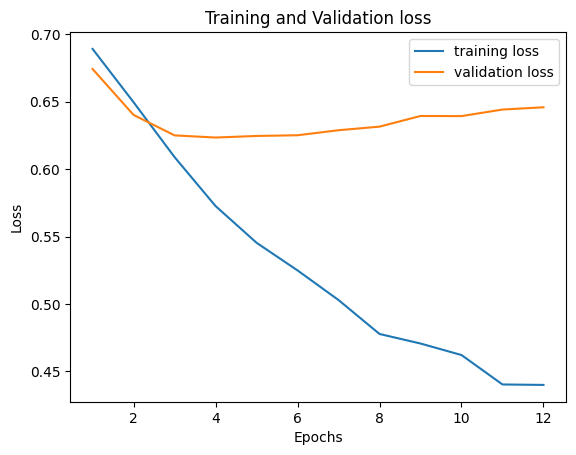

In [ ]:
from matplotlib import pyplot as plt
epochs = range(1, EPOCHS +1 )
fig, ax = plt.subplots()
ax.plot(epochs,train_loss_per_epoch,label ='training loss')
ax.plot(epochs, val_loss_per_epoch, label = 'validation loss' )
ax.set_title('Training and Validation loss')
ax.set_xlabel('Epochs')
ax.set_ylabel('Loss')
ax.legend()
plt.show()

## Performance Metrics
It's common to use precision, recall, and F1-score as the performance metrics.

In [ ]:
label_names = ['negative', 'positive']
label_names

['negative', 'positive']

In [ ]:
from sklearn.metrics import classification_report
print('classifiation report')
print(classification_report(valid_pred, valid_label.to_numpy(), target_names=label_names))

classifiation report
              precision    recall  f1-score   support

    negative       0.72      0.65      0.68       305
    positive       0.64      0.72      0.68       267

    accuracy                           0.68       572
   macro avg       0.68      0.68      0.68       572
weighted avg       0.68      0.68      0.68       572



## Error Analysis
With the predictions, we can plot the confusion matrix:

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
def plot_confusion_matrix(y_preds, y_true, labels=None):
  cm = confusion_matrix(y_true, y_preds, normalize="true")
  fig, ax = plt.subplots(figsize=(6, 6))
  disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
  disp.plot(cmap="Blues", values_format=".2f", ax=ax, colorbar=False)
  plt.title("Normalized confusion matrix")
  plt.show()

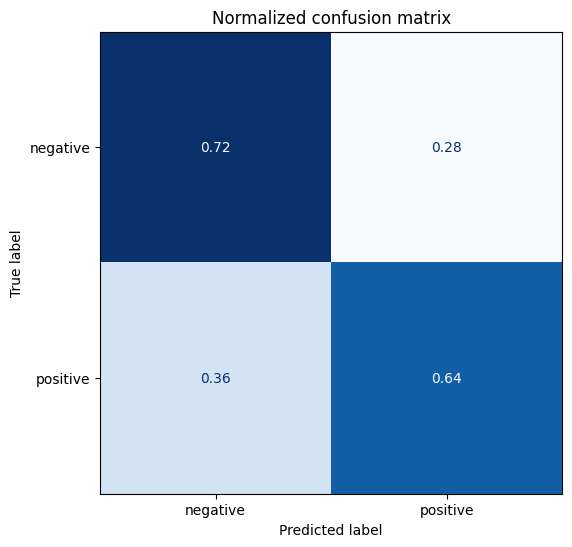

In [ ]:
plot_confusion_matrix(valid_pred,valid_label.to_numpy(),labels=label_names)

## Prediction

*Now* let's use the trained model to predict the testing set.



In [ ]:
model.eval()
test_pred = []
test_loss= 0
with torch.no_grad():
    for step_num, batch_data in tqdm(enumerate(test_dataloader)):
        input_ids, att_mask, labels = [data.to(device) for data in batch_data]
        output = model(input_ids = input_ids, attention_mask=att_mask, labels= labels)

        loss = output.loss
        test_loss += loss.item()

        test_pred.append(np.argmax(output.logits.cpu().detach().numpy(),axis=-1))
test_pred = np.concatenate(test_pred)

0it [00:00, ?it/s]

In [ ]:
print('classifiation report')
print(classification_report(test_pred, test_label.to_numpy(),target_names=label_names))

classifiation report
              precision    recall  f1-score   support

    negative       0.71      0.70      0.71       388
    positive       0.65      0.67      0.66       328

    accuracy                           0.68       716
   macro avg       0.68      0.68      0.68       716
weighted avg       0.69      0.68      0.68       716



With the predictions, we can plot the confusion matrix again:

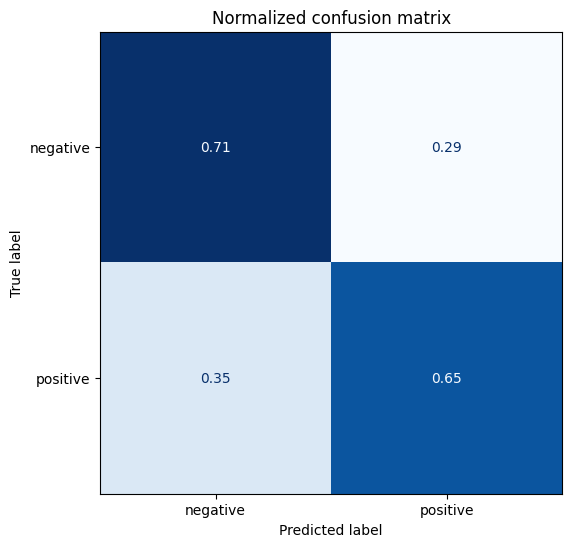

In [ ]:
plot_confusion_matrix(test_pred,test_label.to_numpy(),labels=label_names)

Output the misclassified text:

In [ ]:
test_df['pred'] = test_pred
test_df['label'] = test_label
test_df.reset_index(level=0)
print(test_df[test_df['label']!=test_df['pred']].shape)
test_df[test_df['label']!=test_df['pred']][['text','label','pred']].head(10)

(226, 3)


,text,label,pred
3115,"Oieeee, amoresss! Tô mtooo emocionadaaaa! MINH...",0,1
1013,"o conteúdo é o mesmo, e um beijo gay não é mai...",0,1
448,"A opinião deste tal juiz, que praticamente imp...",1,0
986,Cristãos maltratam gays e mimimi _,0,1
4553,RT responde sua esquerdista de merda,1,0
1202,DOMINGO 19:32 ESCONDE O REVOLVER PAGA AS PROST...,1,0
499,"moço, esse é um post do Facebook que automatic...",1,0
4504,RT 6- emily fields só se fode emaya era lindo ...,0,1
869,burra pq não concordo com vcs? Pensei q a mulh...,0,1
3648,Qdo te vejo meu coração tb dispara e manda (mt...,0,1


In [ ]:
#hide
test_df.to_csv("test_results.csv",index= False)

In [ ]:
MODEL_PATH = "model-BERTimbau-Base.bin"
torch.save(model.state_dict(), MODEL_PATH)

In [ ]:
# mount it
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import shutil
# Use the correct model file name used during saving.
shutil.copy('/content/model-BERTimbau-Base.bin', '/content/drive/MyDrive/model-BERTimbau-Base.bin')

'/content/drive/MyDrive/model-BERTimbau-Base.bin'

In [ ]:
shutil.copy('/content/test_results.csv', '/content/drive/MyDrive/test_results_BAU.csv')

'/content/drive/MyDrive/test_results_BAU.csv'

In [ ]:
!pip install lime

In [ ]:
from lime.lime_text import LimeTextExplainer

In [ ]:
def createDataloader(text):
  test_input_ids, test_att_masks = encode([text])
  BATCH_SIZE = 16
  test_y = torch.LongTensor([0])
  test_dataset = TensorDataset(test_input_ids, test_att_masks, test_y)
  test_sampler = SequentialSampler(test_dataset)
  test_dataloader = DataLoader(test_dataset, sampler=test_sampler, batch_size=BATCH_SIZE)
  return test_dataloader

1it [00:00, 96.04it/s]


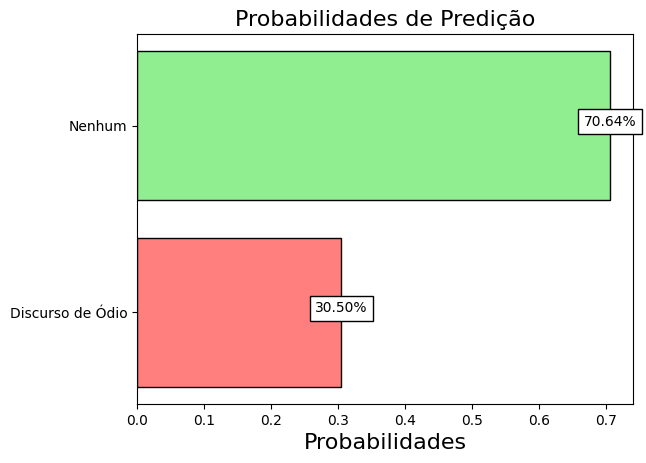

In [ ]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.special import expit  # Assumindo que você esteja usando a função expit do scipy

def predict(text, labels_names):
    model.eval()
    test_dataloader = createDataloader(text)

    with torch.no_grad():
        for step_num, batch_data in tqdm(enumerate(test_dataloader)):
            input_ids, att_mask, labels = [data.to(device) for data in batch_data]
            output = model(input_ids=input_ids, attention_mask=att_mask, labels=labels)

            logits = output.logits.cpu().detach().numpy()
            index_pred = np.argmax(logits, axis=-1)[0]
            probabilities = expit(logits)[0]

    df = pd.DataFrame(columns=['Label', 'Probabilidade'])
    df['Label'] = labels_names
    df['Probabilidade'] = probabilities

    return index_pred, labels_names[index_pred], df

labels_names = ["Discurso de Ódio", "Nenhum"]
# Discurso de Odio
text = "Tem dias que eu vou mais sapatao do que as próprias sapatao, como hoje"

index_pred, label, df = predict(text, labels_names)

def addlabels(x, y):
    for i in range(len(x)):
        plt.text(y[i], i, str(f'{y[i]*100:0.2f}%'), ha='center', bbox=dict(facecolor='white', alpha=1.0))

plt.clf()

pos = np.arange(len(df['Label'].values))
probabilidades = df['Probabilidade'].values

# Vermelho mais claro para Discurso de Ódio, Linguagem ofensiva azul, Verde nenhum.
# Definir as cores para cada classe

color_map = {'Nenhum': '#90EE90', 'Discurso de Ódio': '#FF7F7F'}
colors = df['Label'].map(color_map).fillna('gray')  # Preencher NaN com a cor cinza

# Criar o gráfico de barras
fig = plt.barh(pos, probabilidades, color=colors, edgecolor='black')
plt.yticks(pos, df['Label'])  # Exibir cada classe no eixo y
plt.xlabel('Probabilidades', fontsize=16)
addlabels(pos, probabilidades)  # Chamar a função para adicionar rótulos de valores
plt.title('Probabilidades de Predição', fontsize=16)
plt.show()


In [ ]:
def predict_proba(sentences):
  model.eval()
  probabilities = []

  test_input_ids, test_att_masks = encode(sentences)
  BATCH_SIZE = 16
  test_y = torch.LongTensor([0] * len(sentences))
  test_dataset = TensorDataset(test_input_ids, test_att_masks, test_y)
  test_sampler = SequentialSampler(test_dataset)
  test_dataloader = DataLoader(test_dataset, sampler=test_sampler, batch_size=BATCH_SIZE)

  with torch.no_grad():
    for step_num, batch_data in tqdm(enumerate(test_dataloader)):
        input_ids, att_mask, labels = [data.to(device) for data in batch_data]
        output = model(input_ids = input_ids, attention_mask=att_mask, labels= labels)

        probabilities.append(expit(output.logits.cpu().detach().numpy()))

  probabilities = np.concatenate(probabilities)

  return probabilities

In [ ]:
labels_names=["Nenhum", "Ódio"]

In [ ]:
explainer = LimeTextExplainer(class_names = labels_names)

In [ ]:
exp = explainer.explain_instance("Tem dias que eu vou mais sapatao do que as próprias sapatao, como hoje", classifier_fn = predict_proba, num_features = 10)

313it [00:11, 28.02it/s]


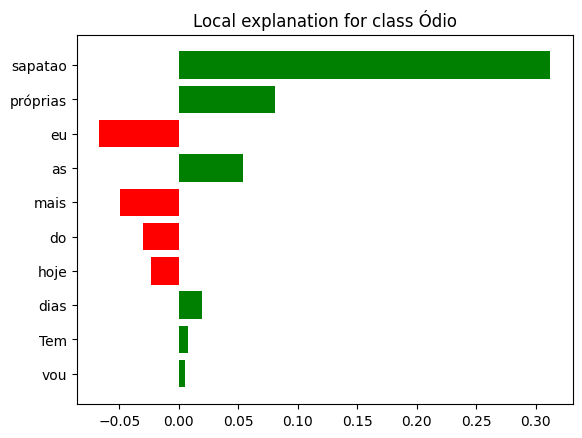

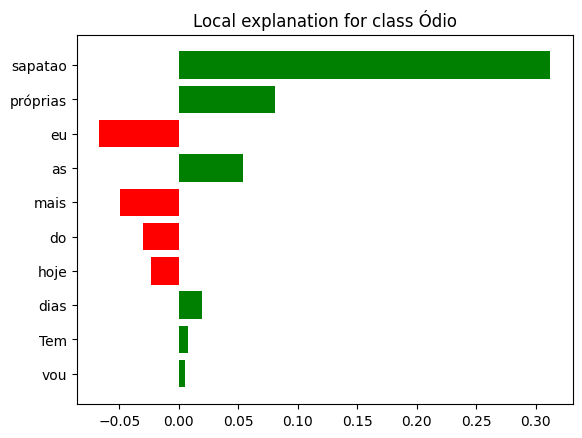

In [ ]:
exp.as_pyplot_figure()

In [ ]:
from IPython.core.display import display, HTML
display(HTML(exp.as_html()))

In [ ]:
exp = explainer.explain_instance('Quero ver essa versão do Mad Max em preto e branco, parece bem maneira', classifier_fn = predict_proba, num_features = 10)

313it [00:09, 33.95it/s]


In [ ]:
from IPython.core.display import display, HTML
display(HTML(exp.as_html()))

In [ ]:
def execute_classify(input):

  if model != None:
    test_pred = predict(input)
    label = labels_names[test_pred[0]]
    return f"A classe prevista foi: {label}"
  else:
    return "Não há texto ou modelo para classificação!"